<a href="https://colab.research.google.com/github/MittalSneha/AI-Disaccharide-Isomers-Identification/blob/main/hNPG_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies (if not already installed)
!pip install dscribe ase matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.4/777.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 9.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ase.build import molecule
from ase import Atoms


In [ ]:
# Load the Excel file
df = pd.read_excel('soap_features.xlsx')

# Drop the first column (assumed to be an ID or label column)
df = df.drop(df.columns[0], axis=1)

# Shuffle the rows randomly
#df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Extract the values for PCA
X = df.values

# Optional: if you want to keep the new row indices as labels
labels = np.arange(len(df))

print("Shuffled descriptor matrix shape:", X.shape)


Shuffled descriptor matrix shape: (460, 3696)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/tmp/ipython-input-770911802.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


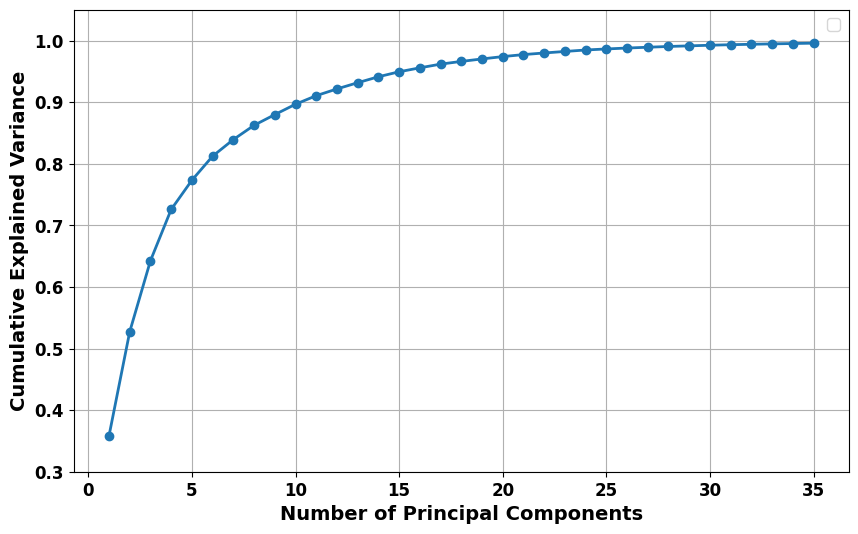

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming X_scaled is your scaled data matrix (n_samples x n_features)
# For example:
# X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=35)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linewidth=2)

# Optional: Add a horizontal line for 90% explained variance threshold
#plt.axhline(y=0.90, color='r', linestyle='--', linewidth=1.5, label='98% Variance Threshold')

plt.xlabel('Number of Principal Components', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.ylim(0.3, 1.05)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


/tmp/ipython-input-593415111.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('viridis')


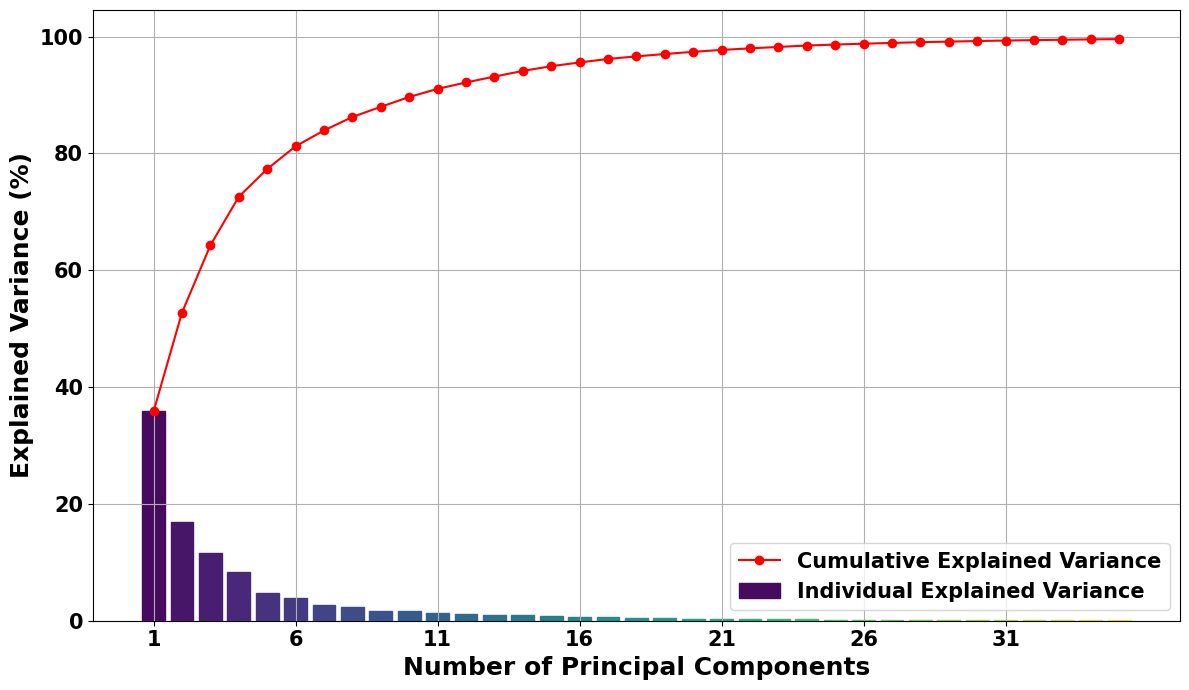

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from matplotlib import cm

# Assuming pca is already fit with n_components=60
individual_explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(individual_explained_variance_ratio)
color_map = cm.get_cmap('viridis')
num_pcs = len(individual_explained_variance_ratio)

plt.figure(figsize=(12, 7))
bars = plt.bar(range(1, num_pcs + 1), individual_explained_variance_ratio * 100,
               align='center', alpha=1, label='Individual Explained Variance')

# Apply gradient color
for i, bar in enumerate(bars):
    bar.set_color(color_map((i + 1) / num_pcs))

# Plot cumulative line
plt.plot(range(1, num_pcs + 1), cumulative_explained_variance_ratio * 100,
         marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')

# Add threshold lines
#plt.axhline(y=95, color='g', linestyle='--', linewidth=1.5, label='95% Variance Threshold')
#plt.axvline(x=25, color='g', linestyle='--', linewidth=1.5, label='PC 25 (95%)')

# Labels and styling
plt.xlabel('Number of Principal Components', fontsize=18, fontweight='bold')
plt.ylabel('Explained Variance (%)', fontsize=18, fontweight='bold')
plt.xticks(ticks=range(1, 35, 5), fontsize=15, fontweight='bold')  # <-- updated line
plt.yticks(fontsize=15, fontweight='bold')
#plt.title('Explained Variance per Principal Component with Cumulative Curve', fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(frameon=True, prop={'size': 15, 'weight': 'bold'})
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

D_original = X_scaled.shape[1]     # original feature count
D_kept = 35                        # PCs you want to retain

reduction_pct = (D_original - D_kept) / D_original * 100
print(f"Keeping {D_kept} PCs reduces dimensionality by {reduction_pct:.2f}%")

Keeping 35 PCs reduces dimensionality by 99.05%


In [ ]:
X_pca.shape

(460, 35)

In [ ]:
x_df = pd.DataFrame(X_pca)
x_df

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,63.855386,-16.878246,45.178165,24.588116,-6.104365,9.969507,-11.946735,-4.729482,4.664399,7.134513,...,-0.623066,-4.810179,0.402678,-2.152240,-1.694013,0.002222,-2.173110,-0.925781,1.715106,0.186439
1,64.186953,-17.078944,45.002545,25.068161,-5.465710,8.790542,-11.747497,-5.659805,7.958483,8.335365,...,-0.769531,-4.394113,0.629429,-1.659351,-1.439149,-0.034829,-1.884990,-1.243269,1.417599,0.531610
2,64.319069,-16.622738,45.155754,24.996617,-4.626271,8.768345,-11.337228,-4.997164,8.607199,7.576903,...,-0.707413,-3.963073,0.843325,-1.287357,-1.105172,0.001324,-1.625958,-1.441046,1.175018,0.896568
3,64.289730,-15.366503,45.772233,24.222739,-3.595296,9.967845,-10.750948,-3.086348,6.257454,4.905052,...,-0.433789,-3.544351,1.026999,-1.050124,-0.725695,0.118613,-1.375578,-1.518845,0.956227,1.218766
4,63.843582,-11.469910,47.866384,21.065133,-1.232473,14.414010,-9.458408,2.749965,-3.997884,-3.817194,...,0.433545,-2.870730,1.260966,-0.947971,0.114036,0.492187,-0.760627,-1.423772,0.475129,1.584516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,-43.063040,-46.240251,33.940353,-5.824883,22.224836,-7.091179,2.847981,-10.774075,-12.776676,-1.248477,...,-1.252404,0.653343,-0.226135,3.422868,-1.458005,1.351676,1.916505,0.862988,0.587381,2.515089
456,-42.158546,-49.897470,33.487662,-4.381667,22.919423,-7.615886,2.482330,-5.803412,-7.865481,-2.859301,...,-1.348632,0.321635,-0.399165,3.249679,-2.037339,1.314883,2.220091,0.739467,0.246274,2.227930
457,-41.065970,-53.552419,32.581340,-2.287755,22.759649,-8.143830,1.903442,0.314306,-3.367396,-4.871839,...,-1.485199,0.160554,-0.341735,3.097325,-2.965795,0.682589,2.000633,0.622490,-0.048843,1.748258
458,-39.623947,-56.561815,31.505311,0.120884,21.532357,-8.650410,1.282999,5.589478,-0.568860,-6.377980,...,-1.546439,0.176180,-0.036386,3.013795,-4.158946,-0.558786,1.227718,0.523226,-0.213005,1.074755


In [ ]:
x_df.to_excel('PC.xlsx', index=False)

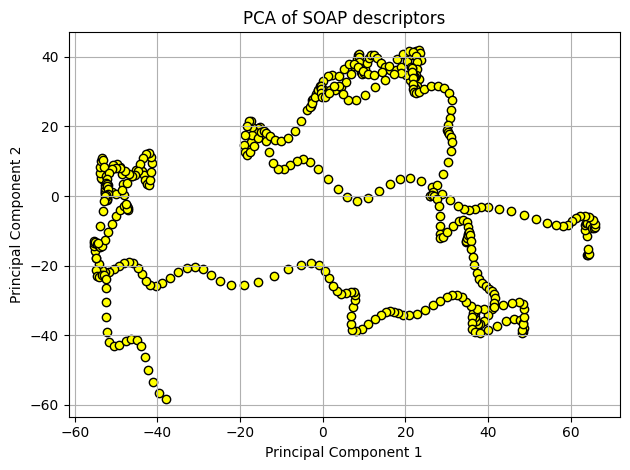

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='yellow', edgecolor='k')
plt.title("PCA of SOAP descriptors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()
